# Design and Optimization of Object Detection using YOLOv8

This project focuses on designing an object detection and multi-object classification system using YOLOv8. The system is trained on a traffic dataset to detect multiple objects such as vehicles and pedestrians.

The dataset was preprocessed and augmented using Roboflow, and the YOLOv8 model was used for training and evaluation. The objective is to build an efficient and optimized object detection pipeline for real-world applications.

In [1]:
!pip install ultralytics
from ultralytics import YOLO
import os
from IPython.display import Image, display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'WeAssist Demos ',
 'Traffic',
 'Review of interfaces.gdoc',
 'Interface review ME.gdoc',
 'bug report 2.gdoc',
 'BUG REPORT.gdoc',
 'Untitled document.gdoc',
 'Doc verification docs req.gdoc',
 'Section wise pres 2.gdoc',
 'Section wise preS.gdoc',
 'Transcript of recordings.gdoc',
 'image.png.gdoc',
 'Movie on 27-02-26 at 1.57\u202fPM.mov',
 'script-4.mov',
 'script-5.mov',
 'script-6.mov',
 'script-8.mov']

In [11]:
zip_path = "/content/drive/MyDrive/Datasets/Traffic"

In [13]:
!ls /content/drive/MyDrive/Traffic

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [14]:
!pip install ultralytics

## Model Training

The YOLOv8 nano model was used for training due to its lightweight architecture and fast performance.

The dataset was structured in YOLO format with separate train, validation, and test folders. The model was trained for 50 epochs with an image size of 640 pixels.

Transfer learning was applied using pretrained weights to improve detection accuracy and reduce training time.

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/Traffic/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Traffic/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c680fb2ae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## Model Evaluation

The trained model was evaluated using key performance metrics:

- Mean Average Precision (mAP)
- Precision
- Recall

These metrics help assess how accurately the model detects and classifies objects in traffic scenarios.


In [16]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 71.8±78.2 MB/s, size: 105.0 KB)
val: Scanning /content/drive/MyDrive/Traffic/valid/labels.cache... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 17.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0s/it 3.1s
                   all         47        254      0.954      0.916      0.947      0.711
                   bus         38         42      0.931      0.905      0.951      0.784
                   car         21        161      0.975      0.969      0.992      0.808
             motorbike          7         12      0.935      0.833      0.866      0.459
                 truck         21         39      0.974      0.956      0.981      0.793
Speed: 7.2ms preprocess, 17.3ms inference,

In [18]:
!ls /content/drive/MyDrive/Traffic/test/images

13805029435_b5d8e3f436_n_jpg.rf.c0e20ca26d2041bb7597fd644ec1e8e4.jpg
14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg
16247264471_bbaaca31f8_w_jpg.rf.68a12fa5fe0fb6469274278d55d32a86.jpg
20788651884_9f0febca65_jpg.rf.d314f303dc0b5306bfd3cb3ef32d2ee2.jpg
22585861694_15d8771622_n_jpg.rf.2ee420a762e9f5d5569c62ac90b25bdc.jpg
28140934815_34b1323f80_w_jpg.rf.5e07d18ea43711c81881c40565d5a8af.jpg
4760177382_064ea0df94_n_jpg.rf.801c0d5f712b5e33bde90afbaa2f3019.jpg
49698443316_793715bf3d_n_jpg.rf.3db921357cb8c79e36cdff8f96ec534d.jpg
5885345648_a67f9c9883_n_jpg.rf.5d8a7fab16fda7bc868c7cc904d1ff06.jpg
5964115893_e116f64081_n_jpg.rf.8cc7699525d787e9bf53e09596eddaf9.jpg
8713872420_17a635ed0b_n_jpg.rf.53cef496a96259d3819076cf70ba3012.jpg
9041139286_666167c849_n_jpg.rf.7958678bdb85c5a73d2bb3baf2f30017.jpg
frame_001_jpg.rf.a343eadf96036330302769151d0c2ab8.jpg
frame_008_jpg.rf.5249910469f489595d8c282aee7abb45.jpg
frame_021_jpg.rf.45595eb9dd9ed5adad0e38c738f2ea9a.jpg
frame_027_jpg.rf.

In [19]:
results = model("/content/drive/MyDrive/Traffic/test/images/14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg")


image 1/1 /content/drive/MyDrive/Traffic/test/images/14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg: 480x640 1 bus, 42.3ms
Speed: 2.5ms preprocess, 42.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)



image 1/1 /content/drive/MyDrive/Traffic/test/images/14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg: 480x640 1 bus, 12.6ms
Speed: 5.0ms preprocess, 12.6ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)


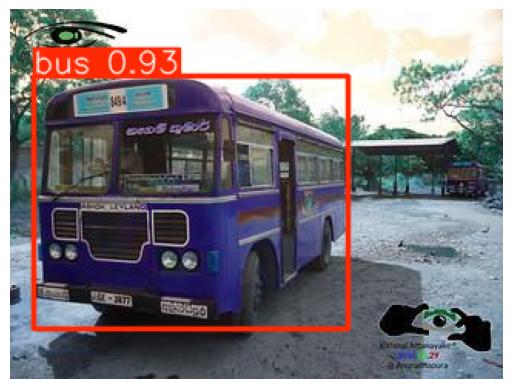

In [21]:
import matplotlib.pyplot as plt

results = model("/content/drive/MyDrive/Traffic/test/images/14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg")

for r in results:
    plt.imshow(r.plot())
    plt.axis('off')
    plt.show()


image 1/23 /content/drive/MyDrive/Traffic/test/images/13805029435_b5d8e3f436_n_jpg.rf.c0e20ca26d2041bb7597fd644ec1e8e4.jpg: 480x640 1 bus, 6.6ms
image 2/23 /content/drive/MyDrive/Traffic/test/images/14463419658_df5c764e4c_n_jpg.rf.ed6f5f60fcfc5ce29559fbc61919b675.jpg: 480x640 1 bus, 6.5ms
image 3/23 /content/drive/MyDrive/Traffic/test/images/16247264471_bbaaca31f8_w_jpg.rf.68a12fa5fe0fb6469274278d55d32a86.jpg: 448x640 2 buss, 40.8ms
image 4/23 /content/drive/MyDrive/Traffic/test/images/20788651884_9f0febca65_jpg.rf.d314f303dc0b5306bfd3cb3ef32d2ee2.jpg: 352x640 1 bus, 39.9ms
image 5/23 /content/drive/MyDrive/Traffic/test/images/22585861694_15d8771622_n_jpg.rf.2ee420a762e9f5d5569c62ac90b25bdc.jpg: 480x640 1 bus, 8.8ms
image 6/23 /content/drive/MyDrive/Traffic/test/images/28140934815_34b1323f80_w_jpg.rf.5e07d18ea43711c81881c40565d5a8af.jpg: 384x640 1 bus, 69.0ms
image 7/23 /content/drive/MyDrive/Traffic/test/images/4760177382_064ea0df94_n_jpg.rf.801c0d5f712b5e33bde90afbaa2f3019.jpg: 480x

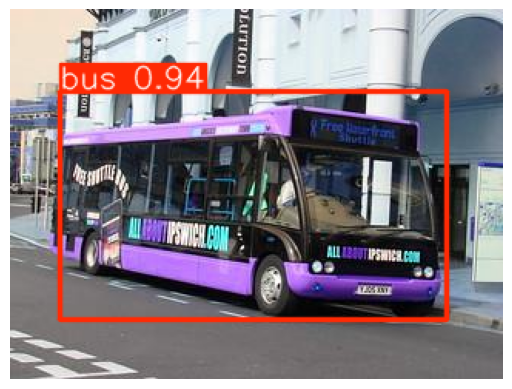

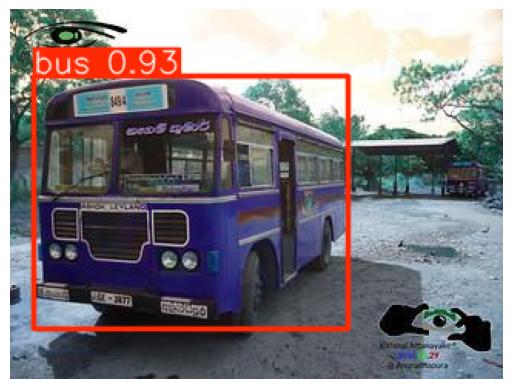

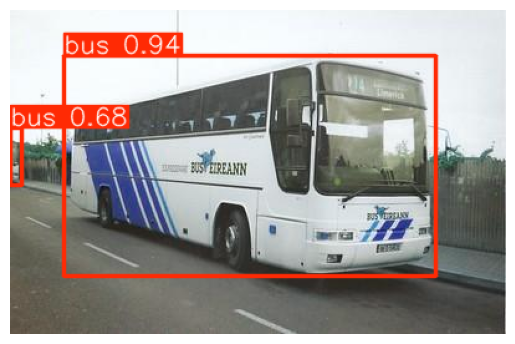

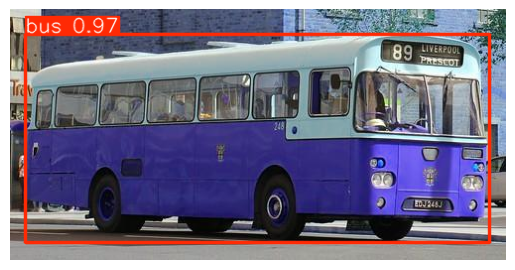

In [22]:
import matplotlib.pyplot as plt

results = model("/content/drive/MyDrive/Traffic/test/images")

for r in results[:4]:  # show 4 images
    plt.imshow(r.plot())
    plt.axis('off')
    plt.show()

## Inference Results

The trained YOLOv8 model was tested on unseen traffic images from the test dataset. The model successfully detected objects such as cars, buses, trucks, and motorbikes.

Bounding boxes with confidence scores were generated, demonstrating strong performance in real-world traffic scenarios.